<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Customer_Segmantation_Using_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using RFM Analysis & K-Means Clustering

## Executive Summary

This project analyzes transactional data from an online retail business to segment customers based on their purchasing behavior, using the **RFM framework** (Recency, Frequency, Monetary) combined with **K-Means clustering**. The goal is to move beyond treating all customers the same and instead identify distinct behavioral groups that can guide targeted marketing, retention, and revenue strategies.

**Dataset:** ~541,000 transaction records from an online retail store (Dec 2010 – Dec 2011), covering ~4,300 unique customers across multiple countries.

### Approach
1. **Data Cleaning** – Removed missing CustomerIDs, duplicate rows, cancelled/returned orders, and non-product transaction codes to ensure only genuine purchases were analyzed.
2. **RFM Feature Engineering** – Calculated Recency (days since last purchase), Frequency (number of transactions), and Monetary (total spend) per customer.
3. **Exploratory Analysis** – Examined distributions and correlations; applied log transformation and standardization to correct for skewness and scale differences ahead of clustering.
4. **Clustering** – Used the Elbow Method and Silhouette Score to determine the optimal number of clusters (K=4), then applied K-Means to segment customers.
5. **Segment Profiling** – Labeled each cluster based on its RFM characteristics and quantified each segment's contribution to overall customer count and revenue.

### Key Result
Customers were grouped into four segments — **Champions, Loyal Customers, New/Promising, and At Risk/Lost**. The analysis revealed a strong Pareto-style imbalance: **Champions make up just ~16% of customers but drive ~64% of total revenue**, while ~38% of customers (At Risk/Lost) haven't purchased recently and contribute minimally to revenue. These findings translate directly into actionable retention and marketing recommendations, detailed at the end of this notebook.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import zipfile

# Unzip the file
with zipfile.ZipFile('/content/OnlineRetail.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print('OnlineRetail.csv.zip extracted successfully.')

OnlineRetail.csv.zip extracted successfully.


In [ ]:
# Load the extracted CSV file into a pandas DataFrame
df = pd.read_csv('/content/OnlineRetail.csv', encoding='ISO-8859-1')

# Display the first 5 rows of the DataFrame
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

##**Data Cleaning**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

Missing values in each column:
 Description      1454
CustomerID     135080
dtype: int64


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")


Number of duplicate rows: 5268


In [ ]:
# Display data types
print("\nData types of each column:\n")
display(df.info())


Data types of each column:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

In [ ]:
# Drop rows where CustomerID or Description is missing, as these are crucial for analysis.
df_cleaned = df.dropna(subset=['CustomerID', 'Description']).copy()

print(f"Original number of rows: {len(df)}")
print(f"Number of rows after dropping missing CustomerID/Description: {len(df_cleaned)}")

Original number of rows: 541909
Number of rows after dropping missing CustomerID/Description: 406829


In [ ]:
# Drop duplicate rows
df_cleaned.drop_duplicates(inplace=True)

print(f"Number of rows after dropping duplicates: {len(df_cleaned)}")

Number of rows after dropping duplicates: 401604


In [ ]:
# Convert 'InvoiceDate' to datetime object with the correct format
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], format='%d-%m-%Y %H:%M')

# Convert 'CustomerID' to integer type
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

print("Data types after conversion:")
display(df_cleaned.info())

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.6+ MB


None

In [ ]:
# Create a new column 'TotalAmount' by multiplying 'Quantity' and 'UnitPrice'
df_cleaned['TotalAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print("DataFrame with 'TotalAmount' column:")
display(df_cleaned.head())

DataFrame with 'TotalAmount' column:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


##**Looking for Cancelled Orders**

In [ ]:
# InvoiceNo starting with 'C' indicates a cancellation/return
cancelled_orders = df_cleaned[df_cleaned['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Number of cancelled order line items: {len(cancelled_orders)}")
print(f"Percentage of total: {len(cancelled_orders)/len(df_cleaned)*100:.2f}%")

display(cancelled_orders.head())

Number of cancelled order line items: 8872
Percentage of total: 2.21%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96


##**Check for negative or zero Quantity/UnitPrice**

In [ ]:
# Negative quantities (returns) and zero/negative prices (data errors or free items)
negative_qty = df_cleaned[df_cleaned['Quantity'] <= 0]
negative_price = df_cleaned[df_cleaned['UnitPrice'] <= 0]

print(f"Rows with Quantity <= 0: {len(negative_qty)}")
print(f"Rows with UnitPrice <= 0: {len(negative_price)}")

# Check if these overlap fully with cancelled orders (InvoiceNo starting with 'C')
non_c_negative_qty = negative_qty[~negative_qty['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Negative quantity rows NOT flagged as cancellations: {len(non_c_negative_qty)}")
display(non_c_negative_qty.head())

Rows with Quantity <= 0: 8872
Rows with UnitPrice <= 0: 40
Negative quantity rows NOT flagged as cancellations: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount


## **Removing Invalid Transactions**

In [ ]:
# Keep only genuine sales: positive quantity, positive price, and not a cancellation
df_cleaned = df_cleaned[
    (~df_cleaned['InvoiceNo'].astype(str).str.startswith('C')) &
    (df_cleaned['Quantity'] > 0) &
    (df_cleaned['UnitPrice'] > 0)
].copy()

print(f"Number of rows after removing cancellations/invalid transactions: {len(df_cleaned)}")

Number of rows after removing cancellations/invalid transactions: 392692


##**Identify and Remove Non Product items**

In [ ]:
# Identify non-standard StockCodes (usually all-letters, no digits)
non_product_codes = df_cleaned[df_cleaned['StockCode'].astype(str).str.match(r'^[A-Za-z\s]+$')]
print("Unique non-product StockCodes found:")
print(non_product_codes['StockCode'].unique())
print(f"\nRows affected: {len(non_product_codes)}")

# Remove these — they aren't real products/customer purchases
df_cleaned = df_cleaned[~df_cleaned['StockCode'].astype(str).str.match(r'^[A-Za-z\s]+$')].copy()
print(f"Number of rows after removing non-product codes: {len(df_cleaned)}")

Unique non-product StockCodes found:
['POST' 'M' 'BANK CHARGES' 'PADS' 'DOT']

Rows affected: 1409
Number of rows after removing non-product codes: 391283


In [ ]:
# Recalculate TotalAmount on the cleaned data
df_cleaned['TotalAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Sanity checks
print(f"Final row count: {len(df_cleaned)}")
print(f"Min Quantity: {df_cleaned['Quantity'].min()}")
print(f"Min UnitPrice: {df_cleaned['UnitPrice'].min()}")
print(f"Min TotalAmount: {df_cleaned['TotalAmount'].min()}")

display(df_cleaned.describe())

Final row count: 391283
Min Quantity: 1
Min UnitPrice: 0.04
Min TotalAmount: 0.06


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,391283.000000,391283,391283.000000,391283.000000,391283.000000
mean,13.141174,2011-07-10 19:37:51.875956736,2.890437,15294.928975,22.346776
min,1.000000,2010-12-01 08:26:00,0.040000,12346.000000,0.060000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.000000,4.950000
50%,6.000000,2011-07-31 12:05:00,1.950000,15157.000000,11.900000
75%,12.000000,2011-10-20 12:57:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000,168469.600000
std,180.777238,NaN,4.375279,1710.146581,310.880067


#**RFM Feature Engineering**

##**We are going to analysis the Customers based on below 3 factors:**
### **R (Recency):** Number of days since last purchase.It will calculate days of purchase since last purchase.
### **F (Frequency):** Number of tracsactions. Number of purchase made by each customers.
### **M (Monetary):** Total amount of transactions (revenue contributed). Total purchase made by each customer.

In [ ]:
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': lambda num: num.nunique(),
    'TotalAmount': 'sum'   # cleaner than recomputing price*qty here
})

rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalAmount': 'Monetary'}, inplace=True)
display(rfm.describe())
display(rfm.head())

,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.703046,4.246654,2017.515838
std,100.177047,7.642535,8920.363571
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.305000
50%,51.000000,2.000000,663.710000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


##**Exploratory Analysis**

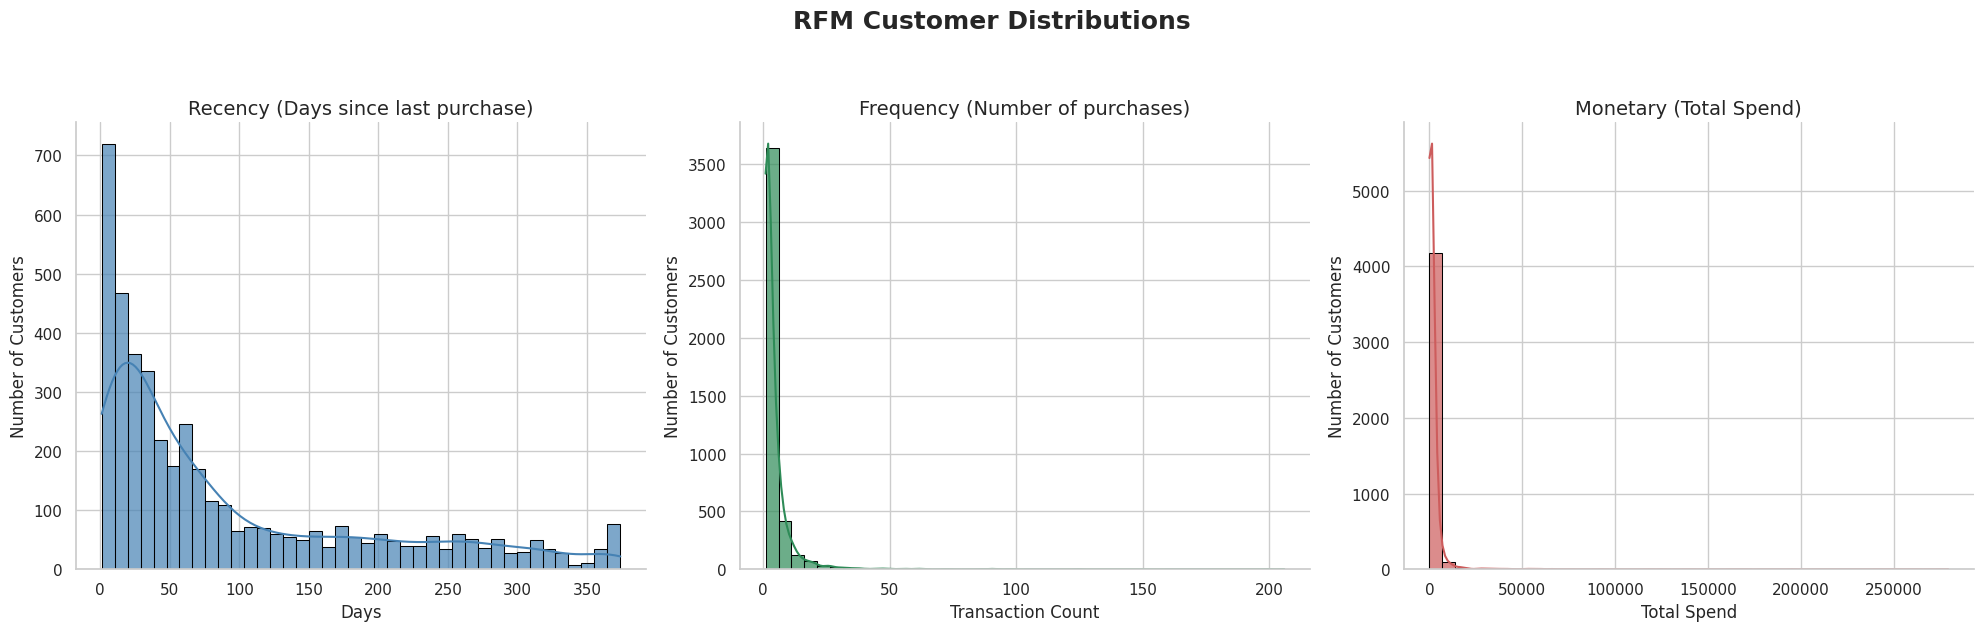

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern aesthetic
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Add a descriptive main title
fig.suptitle('RFM Customer Distributions', fontsize=18, fontweight='bold', y=1.05)

# Plot Recency
sns.histplot(rfm['Recency'], bins=40, kde=True, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Recency (Days since last purchase)', fontsize=14)
axes[0].set_xlabel('Days', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Plot Frequency
sns.histplot(rfm['Frequency'], bins=40, kde=True, ax=axes[1], color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency (Number of purchases)', fontsize=14)
axes[1].set_xlabel('Transaction Count', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)

# Plot Monetary
sns.histplot(rfm['Monetary'], bins=40, kde=True, ax=axes[2], color='indianred', edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary (Total Spend)', fontsize=14)
axes[2].set_xlabel('Total Spend', fontsize=12)
axes[2].set_ylabel('Number of Customers', fontsize=12)

# 2. Despine removes the top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

* **General Observation (Right-Skewness):** All three charts are heavily right-skewed (positively skewed). This means the bulk of your customers cluster at the lower end of the values, with a long "tail" stretching to the right.

##**Log-transformed distributions (to see the "true" shape)**

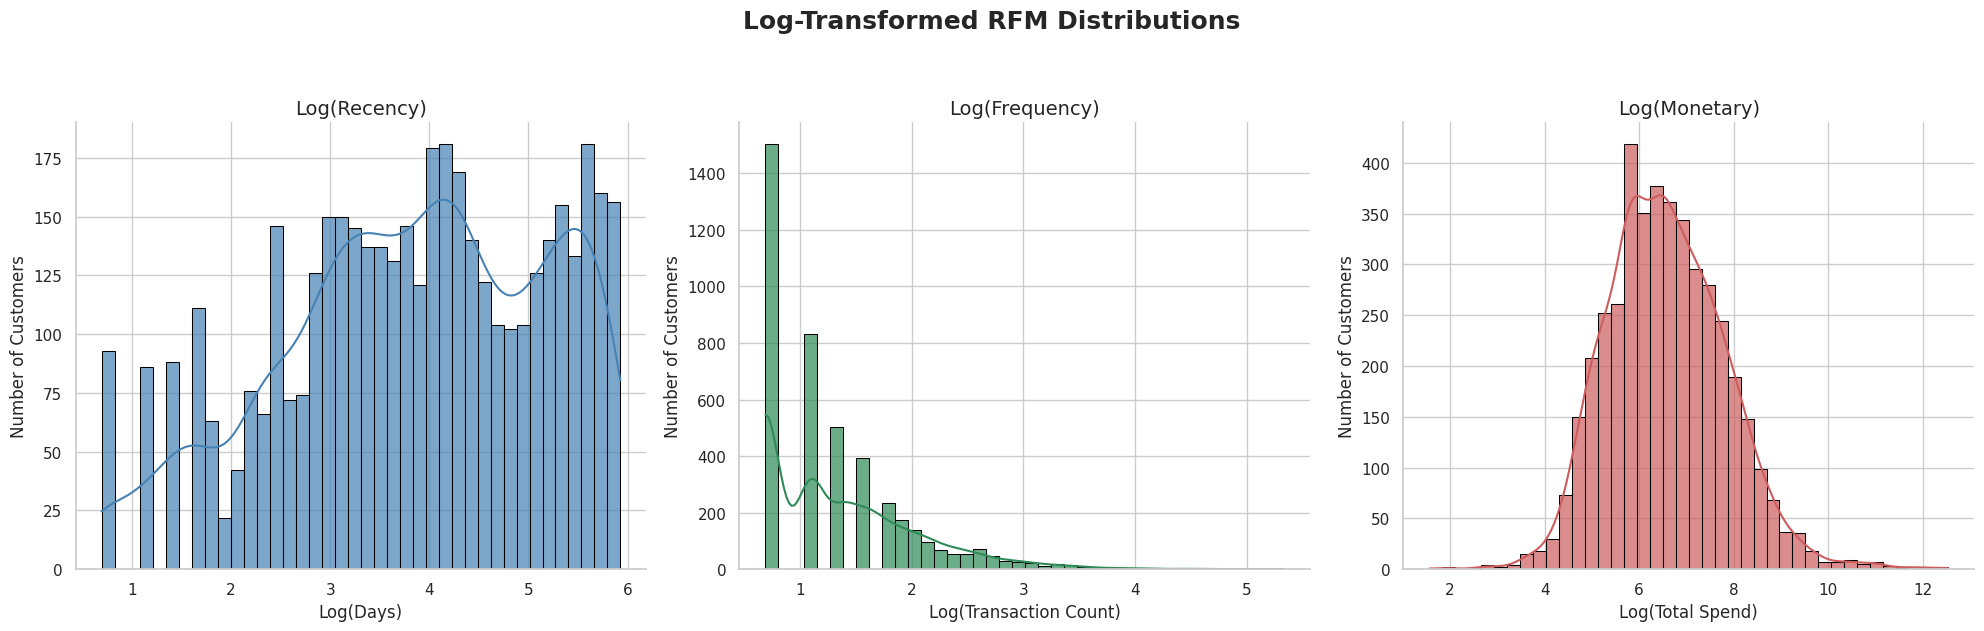

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply log transformation (using log1p to handle zeros gracefully)
rfm_log = rfm.copy()
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])

# Set a clean, modern aesthetic
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Add a descriptive main title
fig.suptitle('Log-Transformed RFM Distributions', fontsize=18, fontweight='bold', y=1.05)

# Plot Log(Recency)
sns.histplot(rfm_log['Recency_log'], bins=40, kde=True, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Log(Recency)', fontsize=14)
axes[0].set_xlabel('Log(Days)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Plot Log(Frequency)
sns.histplot(rfm_log['Frequency_log'], bins=40, kde=True, ax=axes[1], color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Log(Frequency)', fontsize=14)
axes[1].set_xlabel('Log(Transaction Count)', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)

# Plot Log(Monetary)
sns.histplot(rfm_log['Monetary_log'], bins=40, kde=True, ax=axes[2], color='indianred', edgecolor='black', alpha=0.7)
axes[2].set_title('Log(Monetary)', fontsize=14)
axes[2].set_xlabel('Log(Total Spend)', fontsize=12)
axes[2].set_ylabel('Number of Customers', fontsize=12)

# Despine removes the top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

* Recency wide spread indicates distinct groups of customers based on their last purchase date.
* Even after transformation, it is mathematically clear that a huge percentage of our dataset consists of one-time buyers. The clustering algorithm will likely separate these one-time buyers into their own distinct segment.
* The extreme outliers have been successfully compressed for Monetary and normalized data.

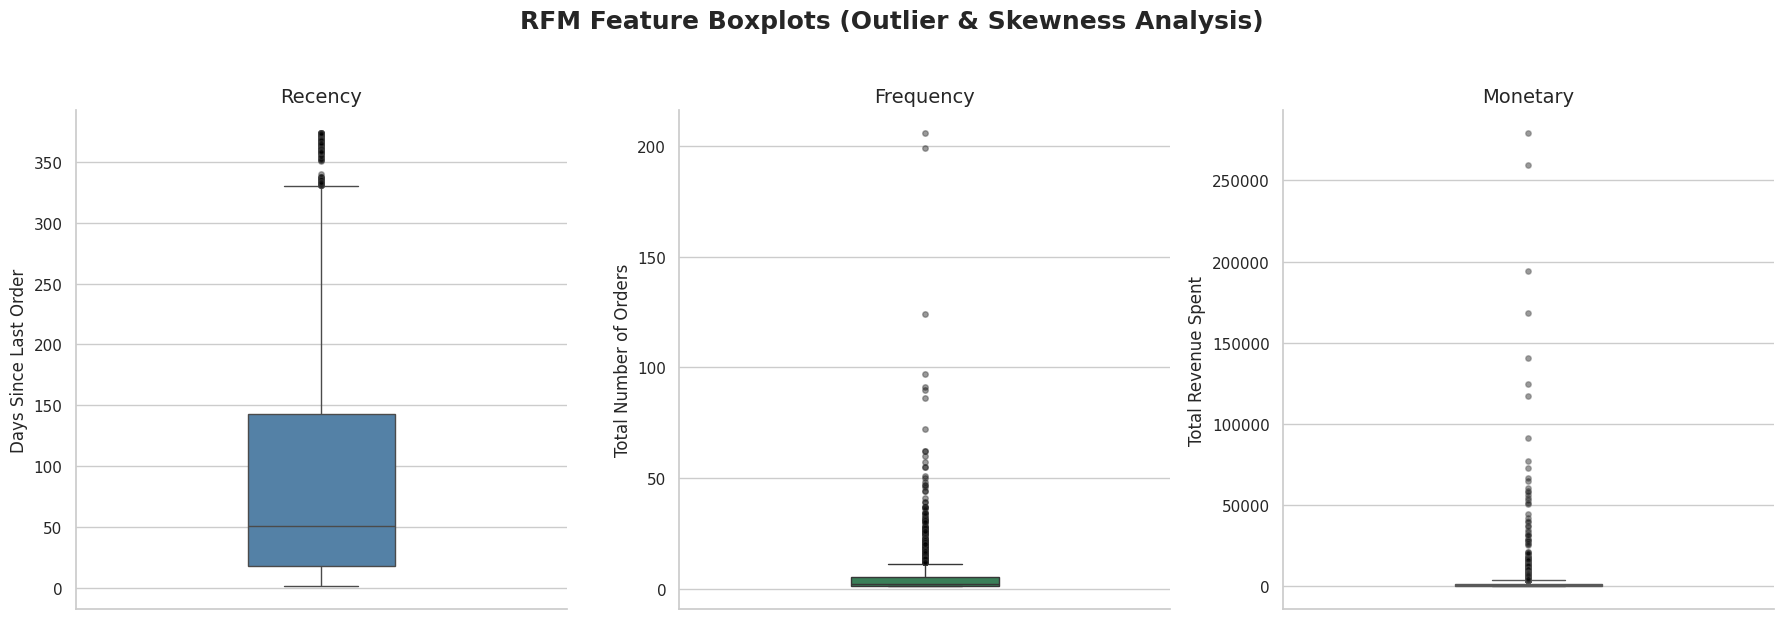

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern style
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Main Title
fig.suptitle('RFM Feature Boxplots (Outlier & Skewness Analysis)', fontsize=18, fontweight='bold', y=1.03)

# Outlier styling for better visibility
flierprops = dict(marker='o', markersize=4, alpha=0.4, markerfacecolor='black')

# Recency Boxplot
sns.boxplot(y=rfm['Recency'], ax=axes[0], color='steelblue', width=0.3, flierprops=flierprops)
axes[0].set_title('Recency', fontsize=14)
axes[0].set_ylabel('Days Since Last Order', fontsize=12)

# Frequency Boxplot
sns.boxplot(y=rfm['Frequency'], ax=axes[1], color='seagreen', width=0.3, flierprops=flierprops)
axes[1].set_title('Frequency', fontsize=14)
axes[1].set_ylabel('Total Number of Orders', fontsize=12)

# Monetary Boxplot
sns.boxplot(y=rfm['Monetary'], ax=axes[2], color='indianred', width=0.3, flierprops=flierprops)
axes[2].set_title('Monetary', fontsize=14)
axes[2].set_ylabel('Total Revenue Spent', fontsize=12)

# Clean up top and right borders
sns.despine()

plt.tight_layout()
plt.show()

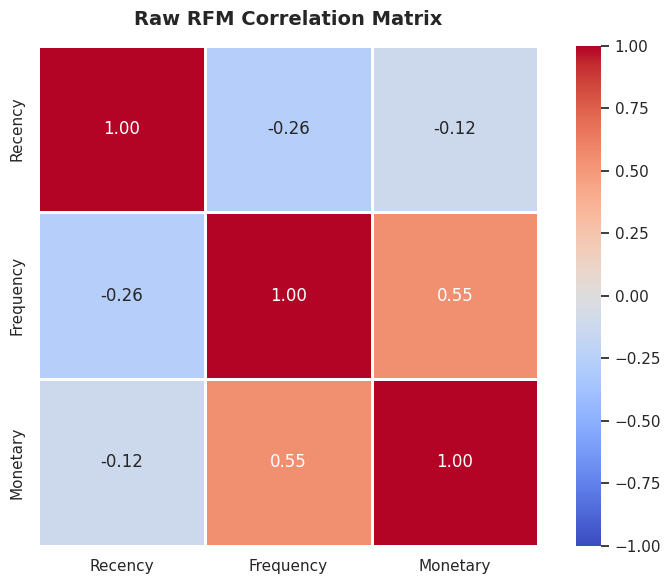

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="white")

# Initialize single plot figure
plt.figure(figsize=(8, 6))

# 1. Raw RFM Correlation Matrix
corr_raw = rfm[['Recency', 'Frequency', 'Monetary']].corr()

# Plot single heatmap with colorbar enabled
sns.heatmap(corr_raw, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=1, square=True, cbar=True)

plt.title('Raw RFM Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

* Strong Positive Correlation between Frequency and Monetary ($r = 0.55$) indicates Customers who buy more frequently almost always accumulate significantly higher total spending.
* Moderate Negative Correlation between Recency and Frequency ($r = -0.26$)
indicates fewer days since their last order buyers correlate with higher purchase counts.

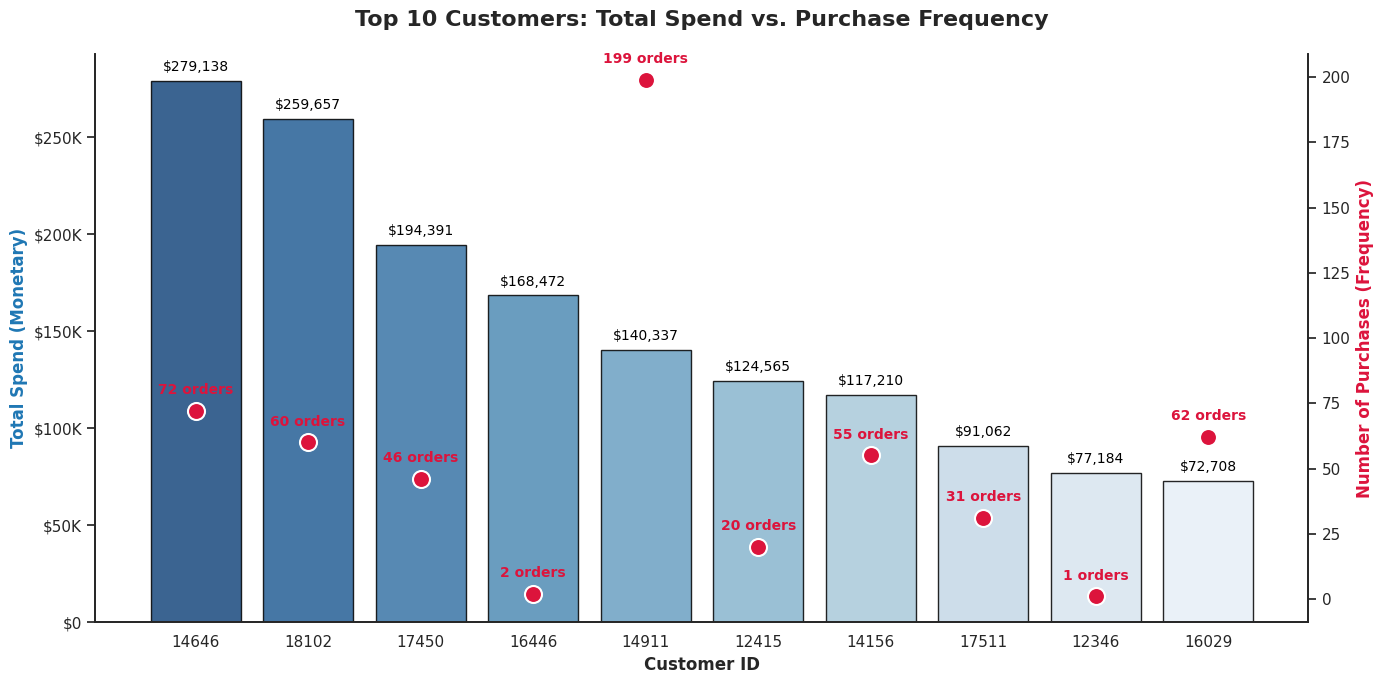

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Get top 10 customers by Monetary value
top_10 = rfm.sort_values('Monetary', ascending=False).head(10).reset_index()
top_10['CustomerID'] = top_10['CustomerID'].astype(str)

# Set a clean aesthetic
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Bar plot for Monetary value (using hue to avoid Seaborn deprecation warnings)
sns.barplot(
    x='CustomerID',
    y='Monetary',
    data=top_10,
    ax=ax1,
    hue='CustomerID',
    palette='Blues_r',
    edgecolor='black',
    alpha=0.85,
    legend=False
)

# Format primary Y-axis as currency (e.g., $250K)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1000:.0f}K' if x >= 1000 else f'${x:.0f}'))
ax1.set_ylabel('Total Spend (Monetary)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_xlabel('Customer ID', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Customers: Total Spend vs. Purchase Frequency', fontsize=16, fontweight='bold', pad=20)

# 2. Add exact spend labels to the top of the bars
for p in ax1.patches:
    ax1.annotate(f'${p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=10, color='black',
                 xytext=(0, 5), textcoords='offset points')

# 3. Create a second y-axis for Frequency
ax2 = ax1.twinx()

# 4. Use a scatter plot for discrete categorical entities, NOT a line plot
sns.scatterplot(
    x='CustomerID',
    y='Frequency',
    data=top_10,
    ax=ax2,
    color='crimson',
    s=150, # Marker size
    edgecolor='white',
    linewidth=1.5,
    zorder=5 # Ensures dots are drawn on top
)
ax2.set_ylabel('Number of Purchases (Frequency)', fontsize=12, fontweight='bold', color='crimson')

# 5. Add exact frequency labels near the scatter dots
for i, txt in enumerate(top_10['Frequency']):
    ax2.annotate(f'{txt} orders',
                 (i, top_10['Frequency'].iloc[i]),
                 ha='center', va='bottom',
                 fontsize=10, color='crimson',
                 fontweight='bold',
                 xytext=(0, 10), textcoords='offset points')

# Clean up dual gridlines to prevent messy overlapping
ax1.grid(False)
ax2.grid(False)

# Remove top spine
sns.despine(top=True, right=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1417/1922934735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='mako')


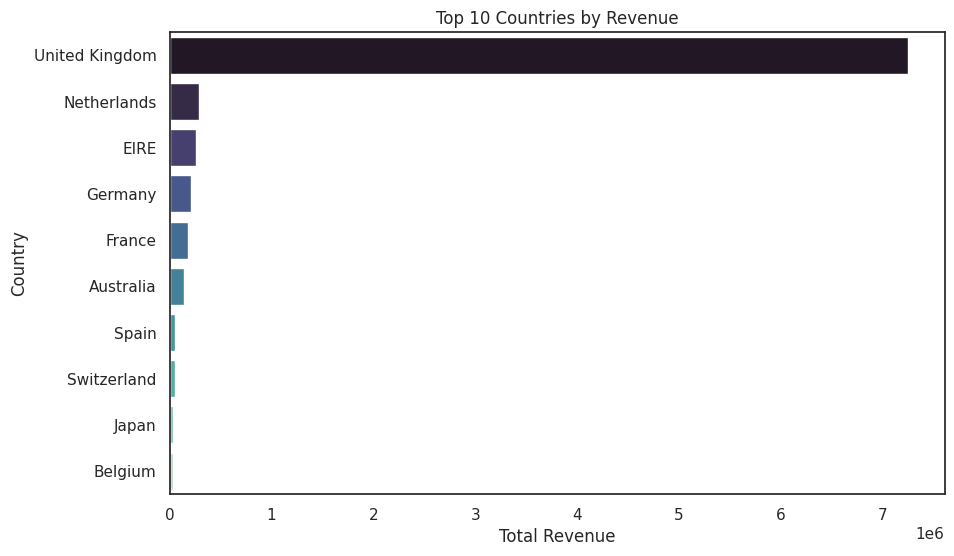

In [ ]:
country_revenue = df_cleaned.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='mako')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()

##**Clustering**

### **Scale the features for Clustering Using Standdard Scaler**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

display(rfm_scaled.describe())

,Recency,Frequency,Monetary
count,4.334000e+03,4.334000e+03,4.334000e+03
mean,4.606888e-16,-1.467318e-16,-5.770905e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341403e+00,-9.512430e-01,-4.000778e+00
25%,-6.621078e-01,-9.512430e-01,-6.816485e-01
50%,8.889316e-02,-3.565098e-01,-6.134806e-02
75%,8.486698e-01,6.601932e-01,6.550641e-01
max,1.562604e+00,5.854045e+00,4.754198e+00


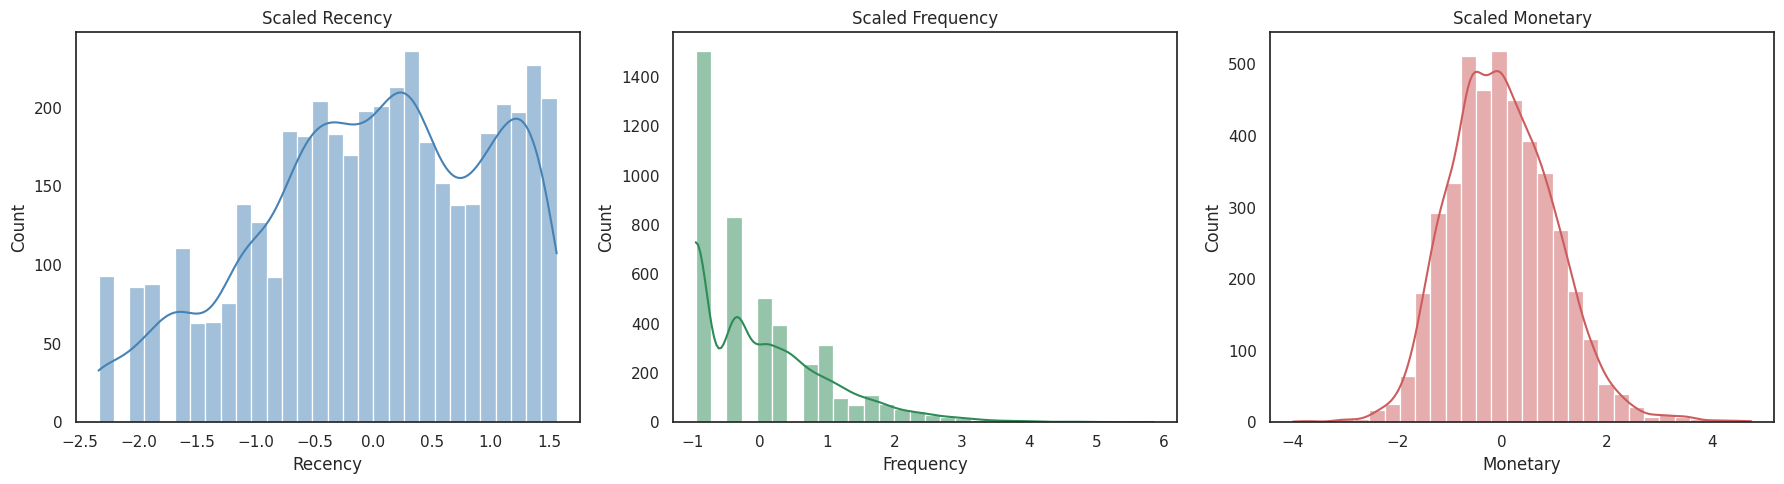

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_scaled['Recency'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Scaled Recency')

sns.histplot(rfm_scaled['Frequency'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Scaled Frequency')

sns.histplot(rfm_scaled['Monetary'], bins=30, kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Scaled Monetary')

plt.tight_layout()
plt.show()

###**Finding optimal number of clusters using Elbow Method and Silhoutte Score to determine the optimal number of clusters (K=4)**

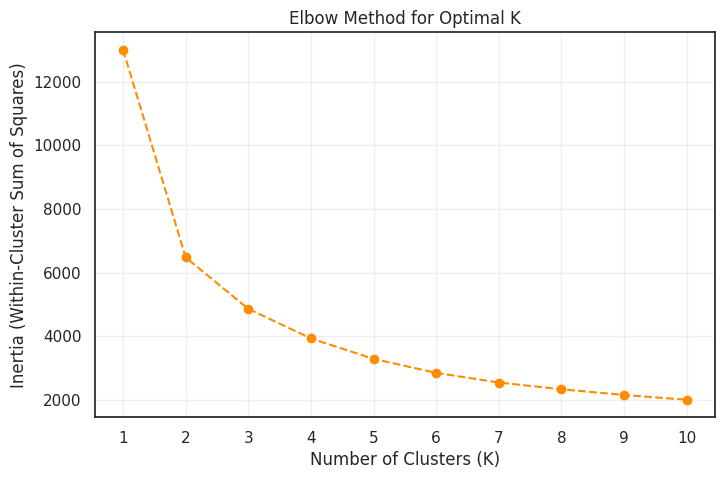

In [ ]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='darkorange')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

K=2, Silhouette Score=0.4329
K=3, Silhouette Score=0.3376
K=4, Silhouette Score=0.3378
K=5, Silhouette Score=0.3166
K=6, Silhouette Score=0.3137
K=7, Silhouette Score=0.3090
K=8, Silhouette Score=0.3020
K=9, Silhouette Score=0.2804
K=10, Silhouette Score=0.2770


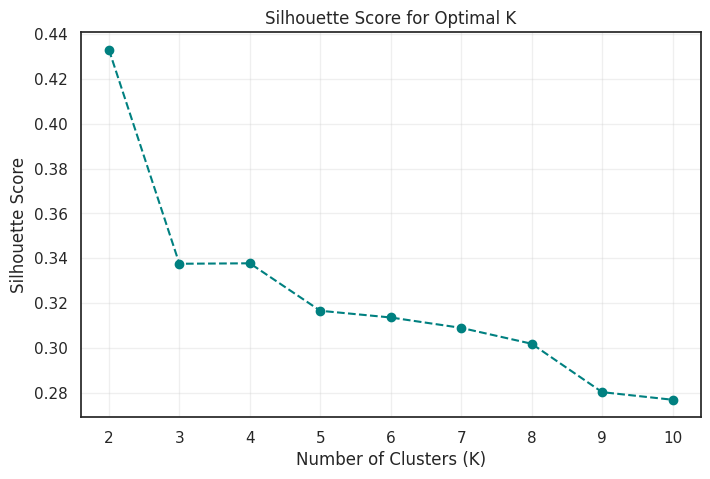

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range_sil, silhouette_scores, marker='o', linestyle='--', color='teal')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.grid(alpha=0.3)
plt.show()

* **K=2** gives the mathematically cleanest separation, but it's usually not useful for a business — it'll likely just split customers into "engaged" vs "disengaged" with no nuance for targeting.
* **K=4** is the better practical choice because:

* It's right at the elbow bend (diminishing returns kick in right after)
Silhouette score at K=4 (0.338) is tied with K=3, and still meaningfully better than K=5+.
* It maps naturally to classic, actionable RFM business segments (e.g., Champions, Loyal Customers, At Risk, Lost/Hibernating) — which is more useful for a  business perspective than 2 broad buckets.

In [ ]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

display(rfm.head())
print(rfm['Cluster'].value_counts())

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,3
12348,75,4,1437.24,2
12349,19,1,1457.55,0
12350,310,1,294.40,1


Cluster
1    1636
2    1174
0     840
3     684
Name: count, dtype: int64


/tmp/ipykernel_1417/3586201027.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=rfm, palette='Set2')


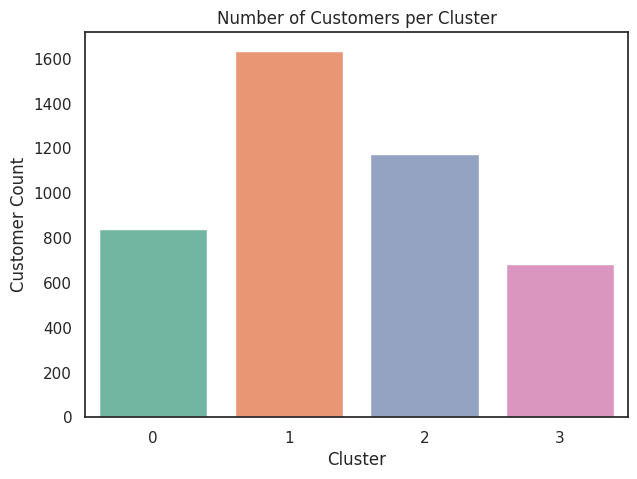

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Cluster', data=rfm, palette='Set2')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.show()

##**Segment Profiling**

In [ ]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
display(cluster_profile)

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,18.5,2.1,531.8,840
1,183.1,1.3,351.6,1636
2,67.0,4.2,1809.1,1174
3,11.7,14.0,8184.3,684


/tmp/ipykernel_1417/444301594.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile_viz.index, y='Recency', data=cluster_profile_viz.reset_index(), ax=axes[0], palette='Set2')
/tmp/ipykernel_1417/444301594.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile_viz.index, y='Frequency', data=cluster_profile_viz.reset_index(), ax=axes[1], palette='Set2')
/tmp/ipykernel_1417/444301594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile_viz.index, y='Monetary', data=cluster_profile_viz.reset_inde

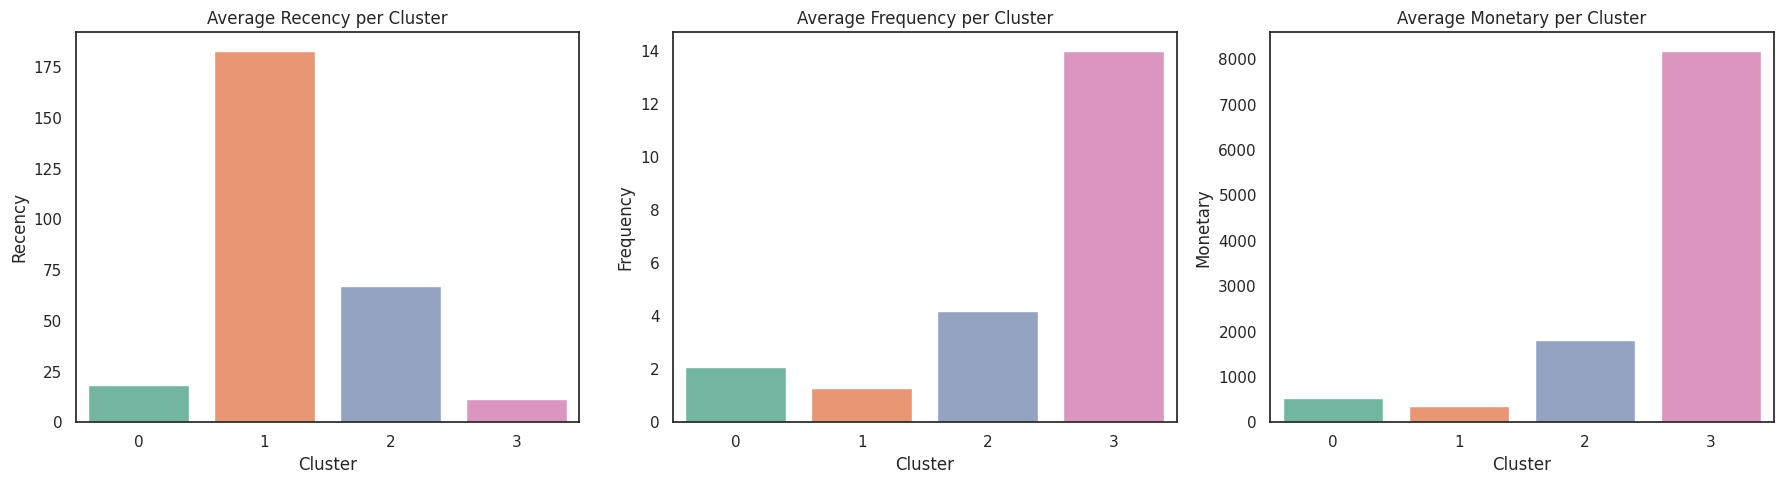

In [ ]:
cluster_profile_viz = cluster_profile[['Recency', 'Frequency', 'Monetary']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=cluster_profile_viz.index, y='Recency', data=cluster_profile_viz.reset_index(), ax=axes[0], palette='Set2')
axes[0].set_title('Average Recency per Cluster')

sns.barplot(x=cluster_profile_viz.index, y='Frequency', data=cluster_profile_viz.reset_index(), ax=axes[1], palette='Set2')
axes[1].set_title('Average Frequency per Cluster')

sns.barplot(x=cluster_profile_viz.index, y='Monetary', data=cluster_profile_viz.reset_index(), ax=axes[2], palette='Set2')
axes[2].set_title('Average Monetary per Cluster')

plt.tight_layout()
plt.show()

**Here we can see that cluster 3 customers are our Best customer. They have low Recency (recent buyer) + high Frequency + high Monetary.**

**Also Cluster 1 customers are our lost(Risk) customer they haven't bought anything for a while.**

##**Labeling the clusters**

In [ ]:
cluster_labels = {
    3: 'Champions',
    2: 'Loyal Customers',
    0: 'New/Promising',
    1: 'At Risk / Lost'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
display(rfm.head())
print(rfm['Segment'].value_counts())

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,2,Loyal Customers
12347,2,7,4310.00,3,Champions
12348,75,4,1437.24,2,Loyal Customers
12349,19,1,1457.55,0,New/Promising
12350,310,1,294.40,1,At Risk / Lost


Segment
At Risk / Lost     1636
Loyal Customers    1174
New/Promising       840
Champions           684
Name: count, dtype: int64


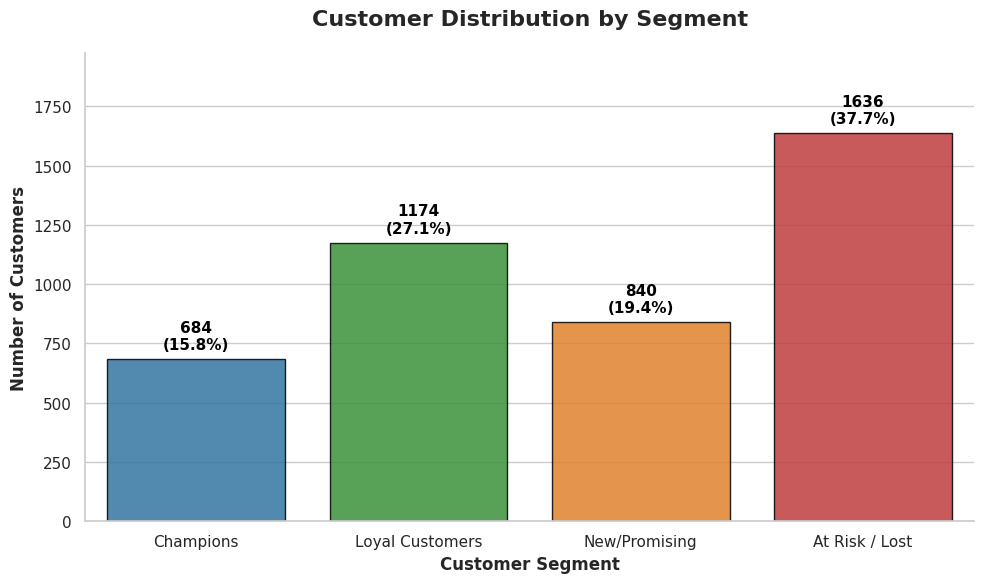

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Semantic color mapping (Green->Good, Blue->Stable, Orange->Warning, Red->Danger)
segment_order = ['Champions', 'Loyal Customers', 'New/Promising', 'At Risk / Lost']
custom_palette = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# 3. Create the plot (using 'hue' to prevent Seaborn warnings in newer versions)
ax = sns.countplot(
    x='Segment',
    data=rfm,
    order=segment_order,
    hue='Segment',
    palette=custom_palette,
    legend=False,
    edgecolor='black',
    alpha=0.85
)

# 4. Add data labels (Count + Percentage)
total_customers = len(rfm)
for p in ax.patches:
    height = p.get_height()
    # Calculate percentage
    percentage = f'{(height / total_customers) * 100:.1f}%'
    # Annotate bar
    ax.annotate(f'{int(height)}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 5. Clean up aesthetics
plt.title('Customer Distribution by Segment', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')

# Expand y-limit slightly so the top labels don't get cut off
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

* The "At Risk / Lost" bucket is your largest segment (approx. ~1,600+ customers): This indicates a high churn rate. A massive portion of your historical customer base has not returned to make a recent purchase.

* A strong, healthy core of "Loyal Customers" (~1,200 customers): You have a solid foundational base of people who purchase somewhat frequently.

* A smaller pipeline of "New/Promising" (~850 customers): Your acquisition is okay, but it is currently being outpaced by your churn rate.

* The "Champions" make up the smallest group (~700 customers): As expected in retail, the highest-tier spenders who buy constantly are the rarest. However, because we saw the massive outliers in your boxplots earlier, we know this small group likely drives a vastly disproportionate percentage of your total revenue.

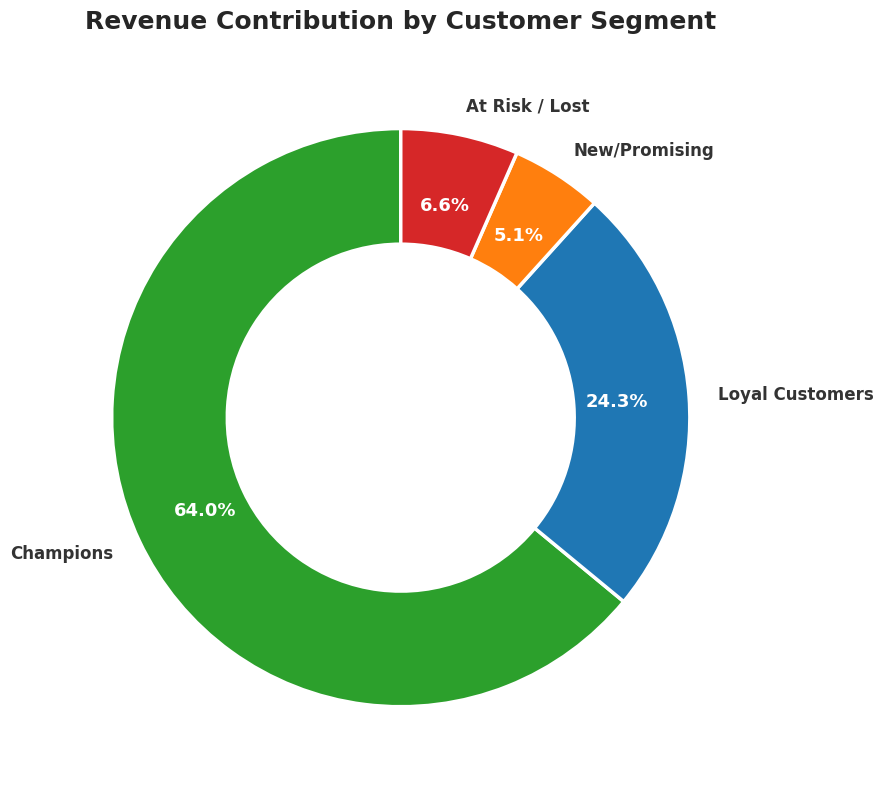

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Enforce semantic color mapping (must match your previous bar chart)
segment_order = ['Champions', 'Loyal Customers', 'New/Promising', 'At Risk / Lost']
custom_palette = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# Calculate total revenue per segment
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().reindex(segment_order)

fig, ax = plt.subplots(figsize=(9, 9))

# 2. Create the Donut Chart using the wedgeprops argument
wedges, texts, autotexts = ax.pie(
    revenue_by_segment,
    labels=segment_order,
    colors=custom_palette,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2.5), # This creates the donut hole
    textprops=dict(fontsize=12, fontweight='bold', color='#333333')
)

# 3. Style the inner percentage text for better contrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

plt.title('Revenue Contribution by Customer Segment', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

* **Champions customers**  make up 64% of total revenue. However, in the previous chart, they were smallest group of customers (only ~700 people). A tiny fraction of audience is single-handedly keeping the business highly profitable.

* **Loyal Customers** provide another 24% of your revenue. Combined with Champions,  top two tiers account for a massive 88% of all money entering the business.

* **"At Risk / Lost"** segment only accounts for 6.6% of historical revenue.Because in previous bar chart, "At Risk / Lost" was your largest segment by volume (over 1,600 people).

##**Hierarchical Clustering (Agglomerative)**

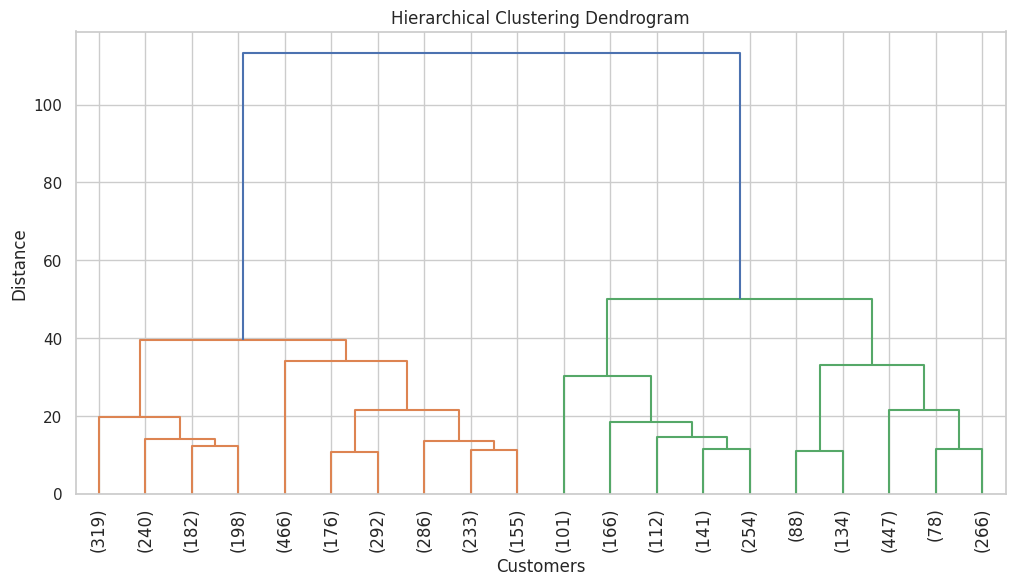

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Dendrogram to visualize merge structure
linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

# Fit with chosen number of clusters
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)

* The dendrogram suggests $K=2$ is the most distinct mathematical split, a binary "Good Customers vs. Bad Customers" segment is rarely actionable for targeted marketing.

##**DBSCAN Algorithm**

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

print(rfm['DBSCAN_Cluster'].value_counts())
# -1 = noise/outlier points, not assigned to any cluster

DBSCAN_Cluster
 0    2765
 1    1489
-1      80
Name: count, dtype: int64


* DBSCAN only found 2 real clusters plus 80 outlier points.
* Here in our dataset the Champions are a small group , dense cluster; every othere segment is spread out more loosely, so it merges most of customers into two big clusters instead of the nuanced 4 clusters.

/tmp/ipykernel_1417/2180481377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=rfm, palette='Set2', ax=axes[0])
/tmp/ipykernel_1417/2180481377.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DBSCAN_Cluster', data=rfm, palette='Set2', ax=axes[1], order=[-1, 0, 1])


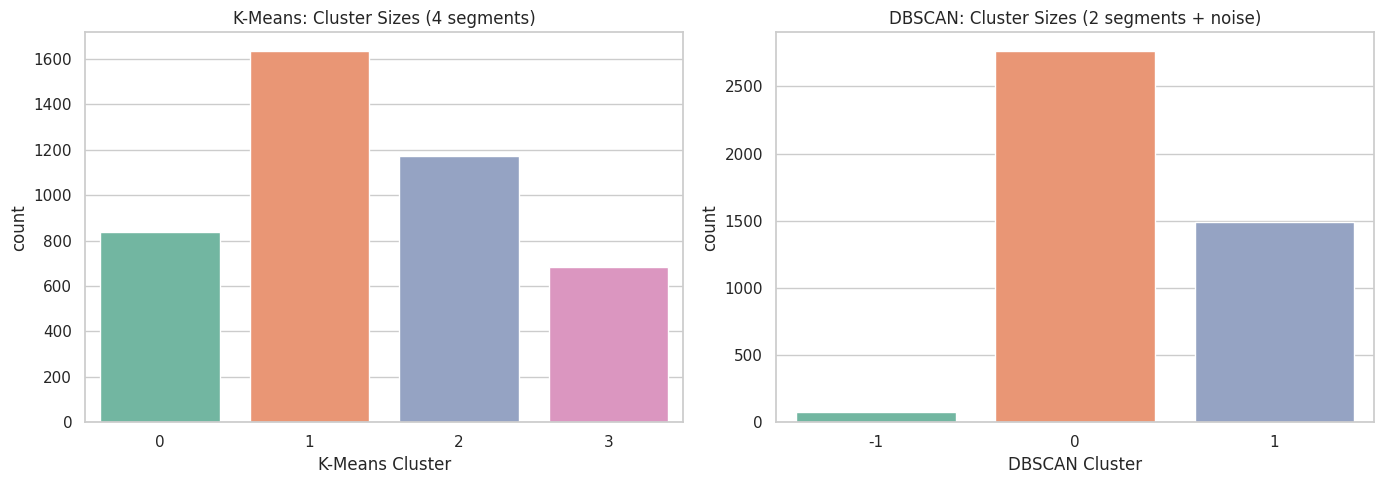

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Cluster', data=rfm, palette='Set2', ax=axes[0])
axes[0].set_title('K-Means: Cluster Sizes (4 segments)')
axes[0].set_xlabel('K-Means Cluster')

sns.countplot(x='DBSCAN_Cluster', data=rfm, palette='Set2', ax=axes[1], order=[-1, 0, 1])
axes[1].set_title('DBSCAN: Cluster Sizes (2 segments + noise)')
axes[1].set_xlabel('DBSCAN Cluster')

plt.tight_layout()
plt.show()

## Key Findings & Business Recommendations

Using RFM analysis and K-Means clustering (K=4), customers were segmented into four distinct groups:

| Segment | % of Customers | % of Revenue | Avg Recency | Avg Frequency | Avg Monetary |
|---|---|---|---|---|---|
| Champions | 16% | 64% | 12 days | 14.0 | ₹8,100 |
| Loyal Customers | 27% | 24% | 67 days | 4.2 | ₹1,800 |
| New/Promising | 19% | 5% | 19 days | 2.1 | ₹500 |
| At Risk / Lost | 38% | 7% | 183 days | 1.3 | ₹300 |

**Key Insight:** A small group of Champions (16% of customers) drives 64% of total revenue — a strong Pareto effect. Meanwhile, over a third of the customer base (At Risk/Lost) has not purchased in ~6 months and contributes minimally to revenue.

### **Recommendations**
- **Champions:** Protect this segment with loyalty rewards, early access to new products, and VIP perks. Losing even a few of these customers has outsized revenue impact.
- **Loyal Customers:** Nurture toward Champion status with personalized upsell/cross-sell offers and consistent engagement.
- **New/Promising:** Focus on onboarding and second-purchase incentives (e.g., a follow-up discount) to build purchase frequency early.
- **At Risk/Lost:** Launch a win-back campaign (targeted discounts, "we miss you" emails). Given their low revenue contribution, prioritize spend on this segment carefully rather than treating it the same as Champions.

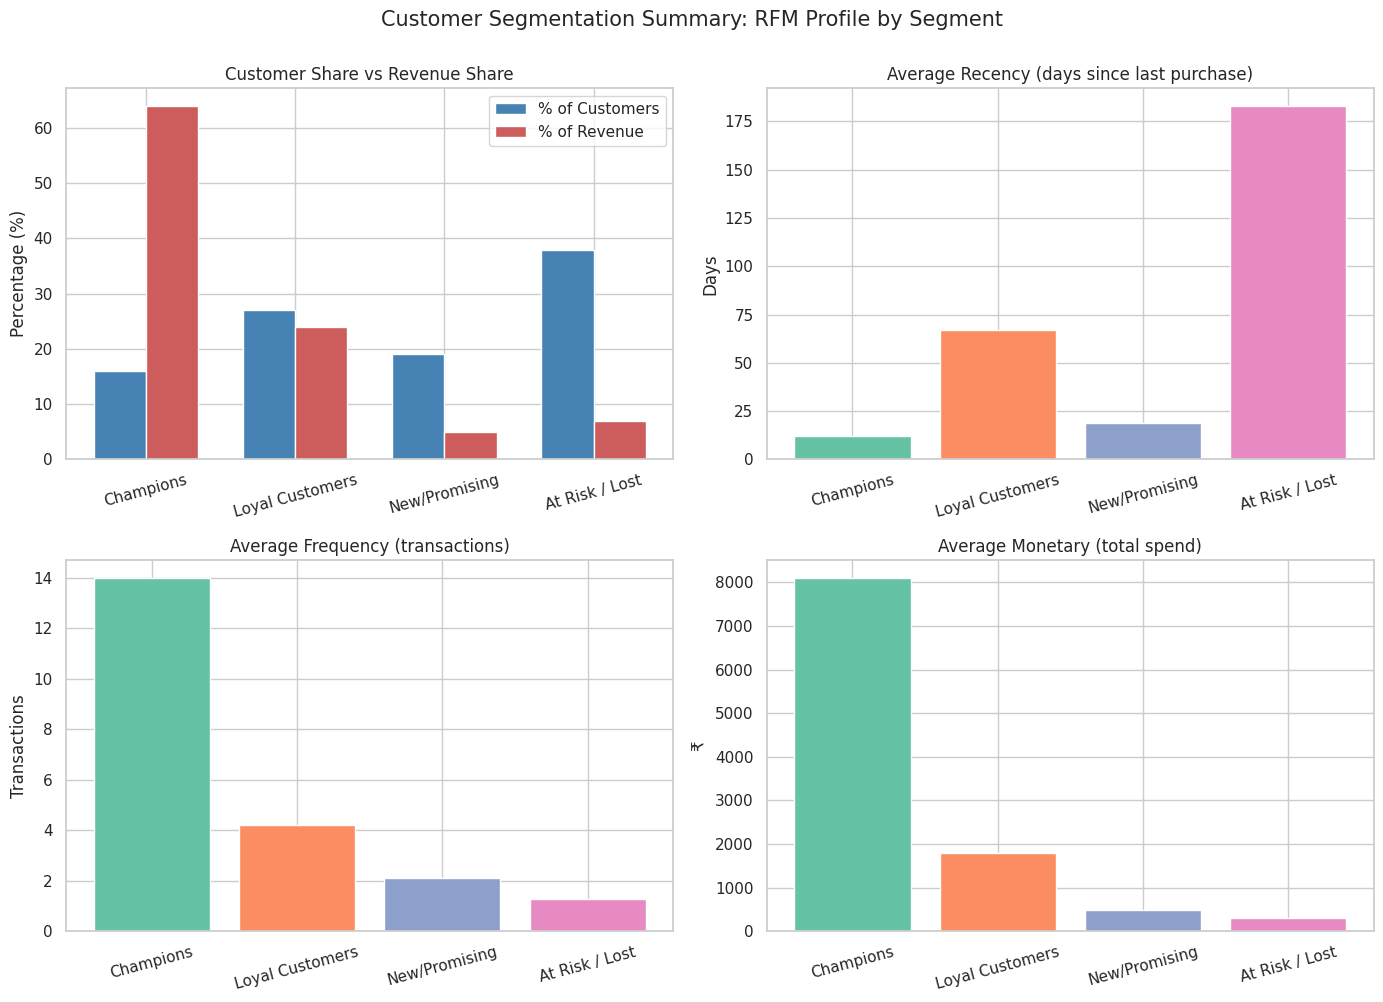

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Recreate the summary table as a DataFrame
summary = pd.DataFrame({
    'Segment': ['Champions', 'Loyal Customers', 'New/Promising', 'At Risk / Lost'],
    'Pct_Customers': [16, 27, 19, 38],
    'Pct_Revenue': [64, 24, 5, 7],
    'Avg_Recency': [12, 67, 19, 183],
    'Avg_Frequency': [14.0, 4.2, 2.1, 1.3],
    'Avg_Monetary': [8100, 1800, 500, 300]
})

colors = ['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Customer % vs Revenue % (the headline Pareto chart)
x = np.arange(len(summary))
width = 0.35
axes[0,0].bar(x - width/2, summary['Pct_Customers'], width, label='% of Customers', color='steelblue')
axes[0,0].bar(x + width/2, summary['Pct_Revenue'], width, label='% of Revenue', color='indianred')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(summary['Segment'], rotation=15)
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].set_title('Customer Share vs Revenue Share')
axes[0,0].legend()

# 2. Average Recency
axes[0,1].bar(summary['Segment'], summary['Avg_Recency'], color=colors)
axes[0,1].set_title('Average Recency (days since last purchase)')
axes[0,1].set_ylabel('Days')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Average Frequency
axes[1,0].bar(summary['Segment'], summary['Avg_Frequency'], color=colors)
axes[1,0].set_title('Average Frequency (transactions)')
axes[1,0].set_ylabel('Transactions')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Average Monetary
axes[1,1].bar(summary['Segment'], summary['Avg_Monetary'], color=colors)
axes[1,1].set_title('Average Monetary (total spend)')
axes[1,1].set_ylabel('₹')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Customer Segmentation Summary: RFM Profile by Segment', fontsize=15, y=1.00)
plt.tight_layout()
plt.show()